## 1) Data Acquasition and Preprocessing

In this section, we import all the necessary libraries and load the **Fashion-MNIST** dataset using the Keras API. 
The dataset consists of 70,000 greyscale images (28x28 pixels) distrubuted across 10 clothing categories.

To prepare the data for our model, we must:
1. *Normalize*: Scale the pixel values from a range of [0,255] to [0,1]. to ensure faster and more stable convergence during training.
2. *Reshape*: Prepare 2 versions of the data. The CNN "Convoloutional Neural Network" which requires a 4D shape `(Batch, Heigh, Width, Channels)`, while the RF "Random Forest" requires a 2D flattened array `(Batch, Features)`.

Finally, we visualize a sample of the images to verify the data labels.

2026-05-30 18:03:55.808884: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


CNN Training Data Shape: (60000, 28, 28, 1)
CNN Test Data Shape: (10000, 28, 28, 1)
RF Training Data SHape: (60000, 784)
RF Test Data SHape: (10000, 784)


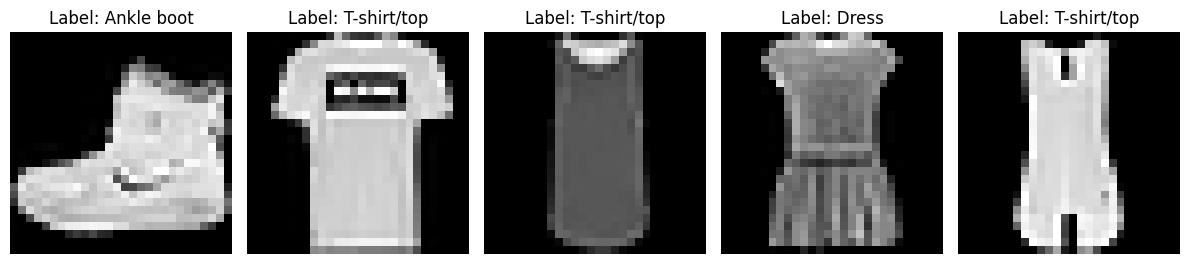

In [1]:
# Importing necessary libraries
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load the dataset
fashion_mnist = keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Class names for visualization and reports
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Normalize the pixel values to float between 0 and 1
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# Reshape data for CNN input (adding single color channel: 28x28x1)
X_train_cnn = X_train_norm.reshape(-1,28,28,1)
X_test_cnn = X_test_norm.reshape(-1,28,28,1)

# Reshape data for Random Forest input (flattening the images to 1D vector: 784 pixels)
X_train_rf = X_train_norm.reshape(len(X_train_norm), -1)
X_test_rf = X_test_norm.reshape(len(X_test_norm), -1)

# VErifying the shapes
print(f"CNN Training Data Shape: {X_train_cnn.shape}")
print(f"CNN Test Data Shape: {X_test_cnn.shape}")
print(f"RF Training Data SHape: {X_train_rf.shape}")
print(f"RF Test Data SHape: {X_test_rf.shape}")


# Visualization of the first 5 images to verify the labels
plt.figure(figsize=(12,3))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train_cnn[i].reshape(28,28), cmap='gray')
    plt.title(f'Label: {class_names[y_train[i]]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 2) Convolutional Neural Netwrok *(CNN)* Architecture & Training

A CNN is implemneted to effectively capture the spatial relationship and visual features of the clothing items.
Unlike a traditional Multi-Layer Perception (MLP) that flattens an image immediately, a CNN uses convolutional filters to detect edges, textures, and shapes while preserving spatial hierarchies.

**Model's Architecture:**
1. **Conv2D Layer (32 filters)**: Extracts basic visual features.
2. **MaxPolling2D Layer**: Downsamples the feature maps, reducing computational load, and the risk of overfiiting.
3. **Conv2D Layer (64 filters)**: Captures more complex, higher-level feature representation.
4. **Flatten Layer**: Converst 2D feature maps into a 1D vector.
5. **Dense Output Layer (10 units)**: Uses a softmax activation function to output the probability distribution across the 10 clothing classes.

The model is compiled using the `adam` optimizer and `sparse_categorical_crossentropy` loss. In-order to evalute the computational efficiency, the total training time is tracked.

In [2]:
# Define CNN model architecture
cnn_model = keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10, activation="softmax")
])

# Display teh model architecture summart
print("CNN Model Achitecture:")
cnn_model.summary()
print("\n")

# Compile the CNN model
cnn_model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

# Train CNN model and record the time taken
print("Training the CNN model (10 Epochs)...")
start_time = time.time()

cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    verbose=1
)

cnn_train_time = time.time() - start_time
print(f"\n CNN Training Complete!")
print(f"Total CNN Training Time: {cnn_train_time:.2f} seconds\n")


CNN Model Achitecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7744)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        77,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 96,266 (376.04 KB)

 Trainable params: 96,266 (376.04 KB)

 Non-trainable params: 0 (0.00 B)



Training the CNN model (10 Epochs)...
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.8515 - loss: 0.4171
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.8990 - loss: 0.2793
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9146 - loss: 0.2360
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9238 - loss: 0.2069
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9332 - loss: 0.1820
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9414 - loss: 0.1613
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9472 - loss: 0.1440
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9536 - loss: 0.1272
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9582 - loss: 0.1142
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9632 - loss: 0.1018

 CNN Training Complete!
Total CNN Training Time: 302.09 se

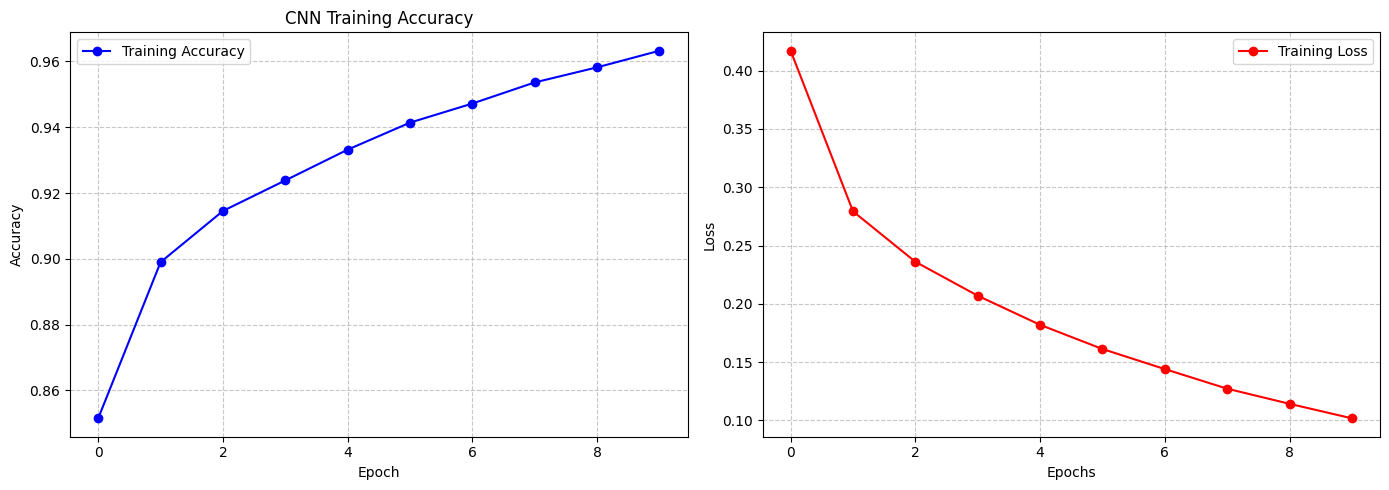

In [3]:
# Training accuracy and loss curve plot for CNN
plt.figure(figsize=(14,5))

# Accuracy Subplot
plt.subplot(1,2,1)
plt.plot(cnn_history.history["accuracy"], marker="o", color="blue", label="Training Accuracy")
plt.title("CNN Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()

# Loss Subplot
plt.subplot(1,2,2)
plt.plot(cnn_history.history["loss"], marker="o", color="red", label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha = 0.7)
plt.legend()

plt.tight_layout()
plt.show()

## 3) Random Forest Classifier Implementation

A traditional machine learning baseline using **Random Forest Classifier** is established to provide a comprehensive evalutaion.
Random Forest is an ensemble learning method that builds multiple decision trees and merges their predictions to improve accuracy and control over-fitting.

Model is initialized with :
* **`n_estimators=100`** : 100 decision trees in the forest
* **`criterion='entripy'`** : To measure the quality of splits
* **`max_depth=100`** : To limit the maximum depth of teh trees

Model training time will be tracked and executed to compare its computational efficiency against CNN.

In [4]:
# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,  # Number of trees in the forest
    criterion="entropy",
    max_depth = 100,
    random_state=42,
    n_jobs = -1  #Uses all CPU cores to speed up training time
)

# Train RF Model and Track Time
print("Training the Ramdom Forest Classifier ....")
start_time = time.time()

rf_model.fit(X_train_rf, y_train)

rf_train_time = time.time() - start_time

print(f"Random Forest Training Complete!")
print(f"Total RF Training Time: {rf_train_time:.2f} seconds\n")

Training the Ramdom Forest Classifier ....
Random Forest Training Complete!
Total RF Training Time: 23.32 seconds



## 4) Comparative Evaluation (Metrics & Confusion Matrices)

Both models are evaluated using the test dataset to test their generalization capabilities on unseen data. Relying solely on overall accuracy can be misleading, so multiple metrics are utilized:
1. **Accuracy**: Overall correctness of the model. By comparing Traning Accuracy vs. Test Accuracy to check for overfitting (a common issue with RF).
2. **Computational Time**: Comparing training time and inference (prediction) time
3. **Classification Report**: Deatiled breakdown of Precison, Recall, and F1-Score for each specific clothing category.
4. **Confusion Matrices**: Visual heatmaps to help identify exactly which clothing classes are confusing with one another.

In [5]:
# Generating Prediction & Measure Inference Time

# --- Random Forest ---
start_time = time.time()
rf_test_pred = rf_model.predict(X_test_rf)
rf_test_time = time.time() - start_time
rf_train_pred = rf_model.predict(X_train_rf)  #For accuracy checking

# --- CNN ---
start_time = time.time()
cnn_predictions = cnn_model.predict(X_test_cnn, verbose=0)
cnn_test_pred = np.argmax(cnn_predictions, axis=1)
cnn_test_time = time.time() - start_time
cnn_train_pred = np.argmax(cnn_model.predict(X_train_cnn, verbose=0), axis=1)


# Calculating Accuracy for both models
rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)
cnn_train_acc = accuracy_score(y_train, cnn_train_pred)
cnn_test_acc = accuracy_score(y_test, cnn_test_pred)


# Comprehensive Comparison Table
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "CNN"],
    "Training Time (s)": [rf_train_time, cnn_train_time],
    "Inference Time (s)": [rf_test_time, cnn_test_time],
    "Train Accuracy": [rf_train_acc, cnn_train_acc],
    "Test Accuracy": [rf_test_acc, cnn_test_acc]
})

print("Overall Model Comparison:")
from IPython.display import display  # A better way to display DataFrames in Jupyter Notebooks
display(comparison_df.round(4))


# Print Classification Reports (Precision, Recall, F1-Score)
print("="*60)
print("RANDOM FOREST CLASSIFIER - TEST SET METRICS")
print("="*60)
print(classification_report(y_test, rf_test_pred, target_names=class_names))

print("\n" + "="*60)
print("CONVOLUTIONAL NEURAL NETWORK - TEST SET METRICS")
print("="*60)
print(classification_report(y_test, cnn_test_pred, target_names=class_names))

Overall Model Comparison:


,Model,Training Time (s),Inference Time (s),Train Accuracy,Test Accuracy
0,Random Forest,23.3220,0.2038,1.0000,0.8773
1,CNN,302.0886,1.4324,0.9677,0.9131


RANDOM FOREST CLASSIFIER - TEST SET METRICS
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.87      0.84      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.77      0.80      0.78      1000
       Dress       0.88      0.91      0.89      1000
        Coat       0.76      0.81      0.79      1000
      Sandal       0.98      0.96      0.97      1000
       Shirt       0.72      0.59      0.65      1000
     Sneaker       0.93      0.96      0.94      1000
         Bag       0.95      0.97      0.96      1000
  Ankle boot       0.96      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


CONVOLUTIONAL NEURAL NETWORK - TEST SET METRICS
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.90      0.85      1000
     Trouser       0.99      0.98      

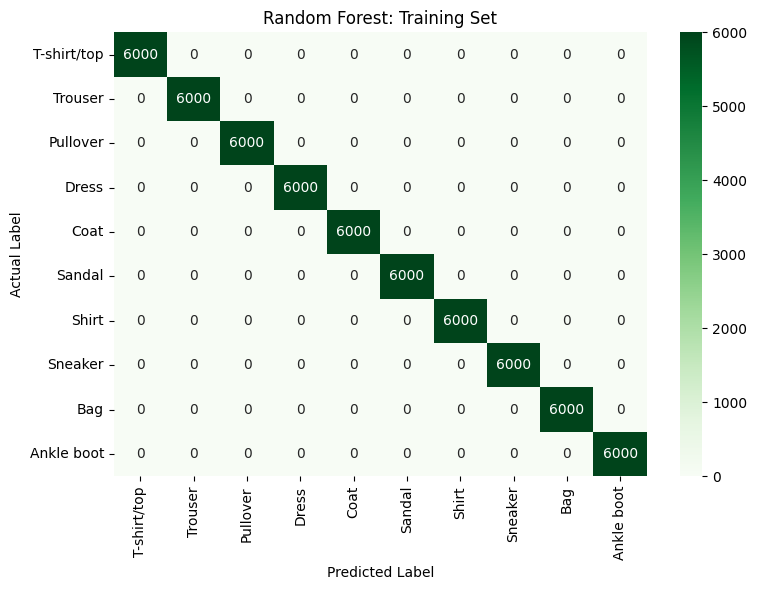

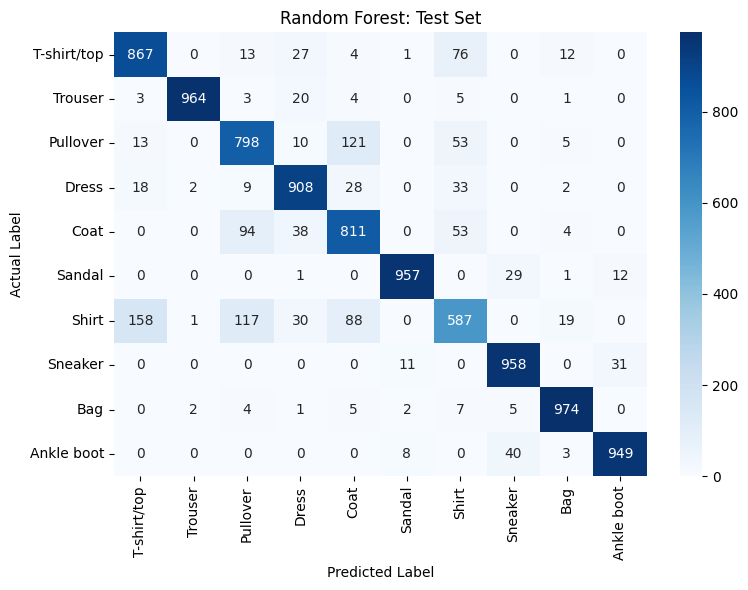

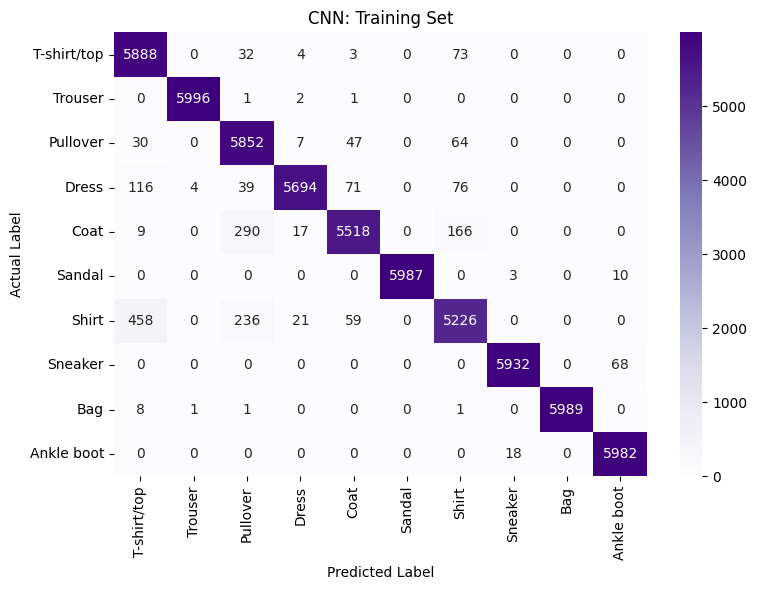

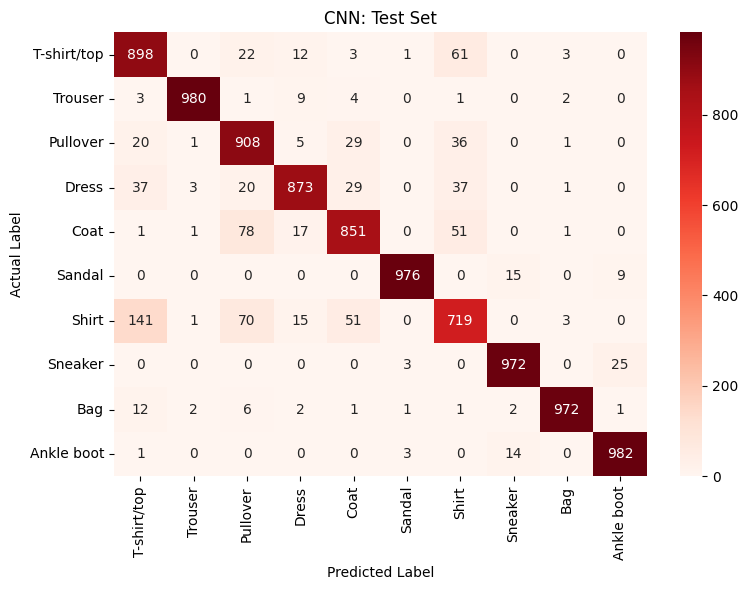

In [6]:
# Confusion Matrix Plot

# --- RF: Training Set ---
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_train, rf_train_pred), annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Random Forest: Training Set')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

# --- RF: Testing Set ---
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, rf_test_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Random Forest: Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

# --- CNN: Training Set ---
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_train, cnn_train_pred), annot=True, fmt='d', cmap='Purples', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('CNN: Training Set')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

# --- CNN: Testing Set ---
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, cnn_test_pred), annot=True, fmt='d', cmap='Reds', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('CNN: Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

## 5) Failure Analysis

Visual inspection of misclassified images is crucial for understanding the model's limitations. By identifying exactly where the CNN predicted the wrong class, a qualitative analysis is performed.

Because the machine works with 28x28 greyscale images, fine-grained details are lost. This leads to the model often confusisng clothing items that shares similar structural silhouettes (e.g., mistaking a "Shirt" for a "T-shirt/Top" or even a "Coat").

Below are 5 examples of these misclassficiation

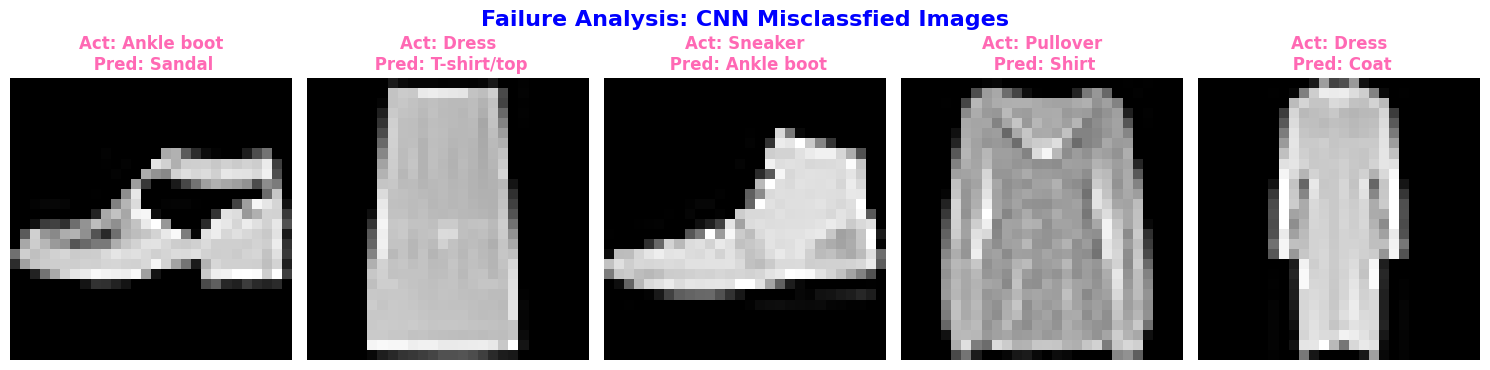

In [7]:
# Find indices where CNN prediction dont match the actual test labels
misclassified_idx = np.where(cnn_test_pred != y_test)[0]

# Visualize 5 misclassified examples
plt.figure(figsize=(15,4))
for i in range(5):
    idx = misclassified_idx[i]

    # plt.subplot (1 row, 5 columns, index i+1) is used to avoid axis array errors
    plt.subplot(1,5,i+1)

    # plot the orginal un-normalized image
    plt.imshow(X_test[idx], cmap='gray')

    actual_label = class_names[y_test[idx]]
    predcited_label = class_names[cnn_test_pred[idx]]

    plt.title(f"Act: {actual_label}\n Pred: {predcited_label}", color="hotpink", fontweight="bold")
    plt.axis('off')

plt.suptitle("Failure Analysis: CNN Misclassfied Images", fontsize=16, fontweight='bold', color='blue')
plt.tight_layout()
plt.show()
